# Load recognition model

In [17]:
from transformers import TableTransformerForObjectDetection, DetrImageProcessor, AutoImageProcessor

structure_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-structure-recognition-v1.1-all").eval().to("cuda")
processor = AutoImageProcessor.from_pretrained("microsoft/table-structure-recognition-v1.1-all")
processor.size = {"shortest_edge": 1500, "longest_edge": 1500}    


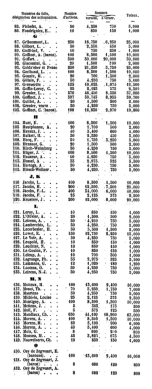

In [24]:
from PIL import Image

cropped_table = Image.open("LabelStudio/output/cropped_e8123784-1906-4_page_1313.png_1851.png").convert("RGB")



from matplotlib import pyplot as plt
plt.imshow(cropped_table)
plt.axis('off')
plt.show()

In [25]:
inputs = processor(images=cropped_table, return_tensors="pt")
inputs = {k: v.to("cuda") for k, v in inputs.items()}
print(inputs["pixel_values"].shape)

torch.Size([1, 3, 1500, 538])


In [26]:
import torch

with torch.no_grad():
    outputs = structure_model(**inputs)

In [27]:
# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(-1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h), (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)


def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

def outputs_to_objects(outputs, img_size, id2label):
    m = outputs.logits.softmax(-1).max(-1)
    pred_labels = list(m.indices.detach().cpu().numpy())[0]
    pred_scores = list(m.values.detach().cpu().numpy())[0]
    pred_bboxes = outputs['pred_boxes'].detach().cpu()[0]
    pred_bboxes = [elem.tolist() for elem in rescale_bboxes(pred_bboxes, img_size)]

    objects = []
    for label, score, bbox in zip(pred_labels, pred_scores, pred_bboxes):
        class_label = id2label[int(label)]
        if not class_label == 'no object':
            objects.append({'label': class_label, 'score': float(score),
                            'bbox': [float(elem) for elem in bbox]})

    return objects

In [28]:
structure_id2label = structure_model.config.id2label
structure_id2label[len(structure_id2label)] = "no object"

cells = outputs_to_objects(outputs, cropped_table.size, structure_id2label)

rows = 0
columns = 0

for cell in cells:
    label = cell["label"]
    if label == "table column":
        columns += 1
    if label == "table row":
          rows += 1


print(cells)

[{'label': 'table column', 'score': 0.9770095348358154, 'bbox': [435.1568603515625, 14.308744430541992, 622.0889892578125, 3290.817626953125]}, {'label': 'table spanning cell', 'score': 0.9882254600524902, 'bbox': [22.417959213256836, 12.7232027053833, 450.706298828125, 134.39817810058594]}, {'label': 'table column', 'score': 0.9946290850639343, 'bbox': [806.6031494140625, 14.094135284423828, 990.6478881835938, 3289.69140625]}, {'label': 'table spanning cell', 'score': 0.9739660620689392, 'bbox': [451.0633239746094, 11.303323745727539, 634.2492065429688, 130.75958251953125]}, {'label': 'table column header', 'score': 0.9812430739402771, 'bbox': [23.08449363708496, 13.42282772064209, 1158.181884765625, 130.36386108398438]}, {'label': 'table column', 'score': 0.9987587928771973, 'bbox': [632.8171997070312, 14.140935897827148, 795.7071533203125, 3289.96337890625]}, {'label': 'table row', 'score': 0.736155092716217, 'bbox': [22.371692657470703, 52.89232635498047, 1158.65380859375, 131.7731

In [29]:
def plot_results(cells, class_to_visualize):

    if class_to_visualize not in structure_model.config.id2label.values():
      raise ValueError("Class should be one of the available classes")

    plt.figure(figsize=(16,10))
    plt.imshow(cropped_table)
    ax = plt.gca()

    for cell in cells:
        score = cell["score"]
        bbox = cell["bbox"]
        label = cell["label"]


        if label == class_to_visualize:
          xmin, ymin, xmax, ymax = tuple(bbox)

          ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color="red", linewidth=3))
          text = f'{cell["label"]}: {score:0.2f}'
          ax.text(xmin, ymin, text, fontsize=15,
                  bbox=dict(facecolor='yellow', alpha=0.5))
          plt.axis('off')

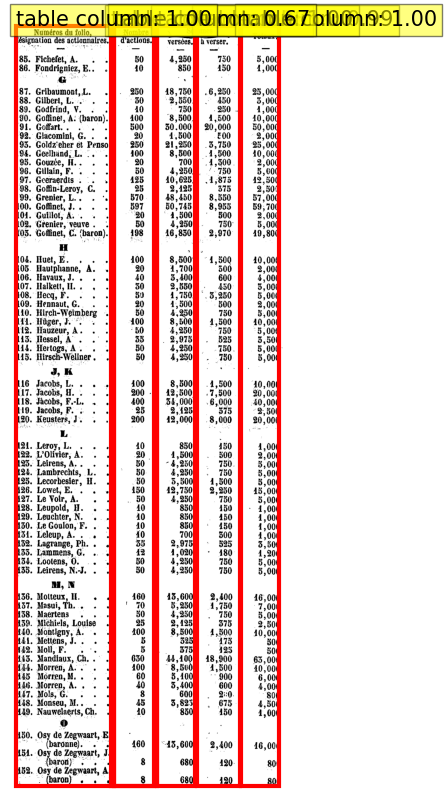

In [31]:
plot_results(cells, class_to_visualize="table column")

In [40]:
def get_cell_coordinates_by_row(table_data):
    # Extract rows and columns
    rows = [entry for entry in table_data if entry['label'] == 'table row']
    columns = [entry for entry in table_data if entry['label'] == 'table column']

    # Sort rows and columns by their Y and X coordinates, respectively
    rows.sort(key=lambda x: x['bbox'][1])
    columns.sort(key=lambda x: x['bbox'][0])

    # Function to find cell coordinates
    def find_cell_coordinates(row, column):
        cell_bbox = [column['bbox'][0], row['bbox'][1], column['bbox'][2], row['bbox'][3]]
        return cell_bbox

    # Generate cell coordinates and count cells in each row
    cell_coordinates = []

    for row in rows:
        row_cells = []
        for column in columns:
            cell_bbox = find_cell_coordinates(row, column)
            row_cells.append({'column': column['bbox'], 'cell': cell_bbox})

        # Sort cells in the row by X coordinate
        row_cells.sort(key=lambda x: x['column'][0])

        # Append row information to cell_coordinates
        cell_coordinates.append({'row': row['bbox'], 'cells': row_cells, 'cell_count': len(row_cells)})

    # Sort rows from top to bottom
    cell_coordinates.sort(key=lambda x: x['row'][1])

    return cell_coordinates

cell_coordinates = get_cell_coordinates_by_row(cells)

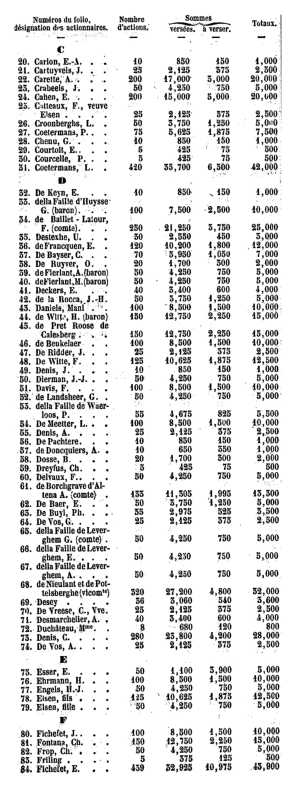

In [41]:
plt.figure(figsize=(16,10))
plt.imshow(cropped_table)
plt.axis('off') 
ax = plt.gca()

all_cropped_images = []
all_cropped_images_coords = []

for row in cell_coordinates:
    for cell in row["cells"]:
        xmin, ymin, xmax, ymax = cell["cell"]
        crop = cropped_table.crop((xmin, ymin, xmax, ymax))
        mean_coord = [(xmin + xmax) / 2, (ymin + ymax) / 2]
        all_cropped_images.append(crop)
        all_cropped_images_coords.append(mean_coord)


## OCR

In [13]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
import base64

model = Qwen2_5_VLForConditionalGeneration.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", torch_dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", min_pixels=128 * 28 * 28, max_pixels=1024 * 28 * 28)

Loading checkpoint shards: 100%|██████████| 5/5 [00:04<00:00,  1.21it/s]
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


In [14]:
import cv2 as cv
import numpy as np
import base64
import re

OCR_output = []


for idx, crop in enumerate(all_cropped_images):

    converted_crop_from_pil_to_cv = cv.cvtColor(np.array(crop), cv.COLOR_RGB2BGR)
    kernel = np.ones((2, 2), np.uint8)
    converted_crop_from_pil_to_cv = cv.erode(converted_crop_from_pil_to_cv, kernel, iterations=1)
    _, buffer = cv.imencode('.png', converted_crop_from_pil_to_cv)
    encoded_image = base64.b64encode(buffer).decode('utf-8')

    prompt = (
  "Transcribe ONLY the visible text in this image.\n"
  "- Do NOT guess or complete words from context.\n"
  "- If a word is cut off, output it exactly as seen.\n"
  "- Output a single line of text. No extra words, no commentary."
)
    
    message = [
                            {
                                "role": "user",
                                "content": [
                                    {"type": "image", "image": f"data:image/png;base64,{encoded_image}"},
                                    {"type": "text", "text": prompt},
                                ],
                            }
                        ]
                    
    text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(message)
    inputs = processor(
                            text=[text],
                            images=image_inputs,
                            videos=video_inputs,
                            padding=True,
                            return_tensors="pt",
                        )
    inputs = inputs.to("cuda")

    generated_ids = model.generate(**inputs, max_new_tokens=32)
    generated_ids_trimmed = [
                        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
                        ]
    text = processor.batch_decode(
                            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
                        )


    cleaned_text = re.sub(r"[^A-Za-zÀ-ÿ0-9,.\s]", "", text[0])
    # Remove dot/comma if it's the only character
    if cleaned_text in [".", ","]:
        cleaned_text = ""
    if cleaned_text and ("the contents" not in cleaned_text.lower()) and ("the image" not in cleaned_text.lower()) and ("the quick brown fox" not in cleaned_text.lower()) and ("none" not in cleaned_text.lower()):
        print(f"OCR output for cell {idx}: {cleaned_text}")
        OCR_output.append((cleaned_text, all_cropped_images_coords[idx]))




OCR output for cell 0: Numéros dordre, prénoms, noms, qualités
OCR output for cell 1: NomI
OCR output for cell 2: N
OCR output for cell 3: Nombre
OCR output for cell 4: e
OCR output for cell 5: et
demeures des actionnaires.
OCR output for cell 6: dactions.
OCR output for cell 7: daction
OCR output for cell 8: ons. de
OCR output for cell 9: de voix.
OCR output for cell 10: M. Félix Vandermeulen, secrétaire communal de Perck, y demeurant, possesseur de deux actions En vertu de proc
OCR output for cell 11: 2
OCR output for cell 15: Ensemble, cinquantedeux actions, donnant droit à dix voix 10. M. Albert Paquot, ingénieur,
OCR output for cell 16: 52
230
OCR output for cell 17: 59
230
OCR output for cell 18: 52
30
OCR output for cell 19: 10
OCR output for cell 20: actions, donnant droit à dix voix
11. M. Charles Goethals, employé, demeurant à
Schaer
OCR output for cell 21: 250
à
x
6
à
OCR output for cell 22: 250
OCR output for cell 23: 6
OCR output for cell 24: 10
OCR output for cell 25: act

# Reconstruct Excel from coords

In [15]:

img_width, img_height = cropped_table.size

def normalize_coords(coord, img_width, img_height):
    x, y = coord
    norm_x = x / img_width
    norm_y = y / img_height
    return (norm_x, norm_y)

real_coords_normalized = [normalize_coords(coord, img_width, img_height) 
                          for text, coord in OCR_output]

def calculate_mean_artificial_coords(amount_of_columns, amount_of_rows):
    artificial_coords = []
    normalized_c = 1 / amount_of_columns
    normalized_r = 1 / amount_of_rows

    print("Step size:", normalized_c, normalized_r)
    for r in range(amount_of_rows):
        for c in range(amount_of_columns):
            artificial_coords.append(((c + 0.5) * normalized_c,
                                      (r + 0.5) * normalized_r))
    return artificial_coords

artificial_coords = calculate_mean_artificial_coords(columns, rows)

aligned = []
for artificial, real in zip(artificial_coords, real_coords_normalized):
    aligned.append((artificial, real))

    


Step size: 0.2 0.05555555555555555


In [16]:
import numpy as np
from collections import defaultdict

import numpy as np

def assign_nearest_per_cell(artificial_coords, real_coords_norm, texts, rows, columns, max_dist=None):
    """
    artificial_coords: list[(ax, ay)] normalized in [0,1], length == rows*columns, row-major
    real_coords_norm: list[(rx, ry)] normalized [0,1] for each OCR text
    texts: list[str] same length as real_coords_norm
    rows, columns: ints
    max_dist: optional float in normalized units; if nearest distance > max_dist, leave empty
    """
    A = np.asarray(artificial_coords, dtype=float)             # (N,2)
    R = np.asarray(real_coords_norm, dtype=float)              # (M,2)
    used = np.zeros(len(R), dtype=bool)

    table = np.empty((rows, columns), dtype=object)
    table[:] = ""

    for i, (ax, ay) in enumerate(A):
        diffs = R - np.array([ax, ay])
        dists = np.linalg.norm(diffs, axis=1)
        dists[used] = np.inf

        j = int(np.argmin(dists))
        d = dists[j]

        if np.isfinite(d) and (max_dist is None or d <= max_dist):
            r, c = divmod(i, columns)
            table[r, c] = (table[r, c] + "\n" if table[r, c] else "") + str(texts[j])
            used[j] = True

    return table


real_coords_norm = [(x / img_width, y / img_height) for _, (x, y) in OCR_output]
texts = [t for t, _ in OCR_output]

table = assign_nearest_per_cell(
    artificial_coords,
    real_coords_norm,
    texts,
    rows,
    columns,
    max_dist=0.12  
)
print(table)


[['' 'et\ndemeures des actionnaires.' '' 'dactions.' 'de voix.']
 [''
  'M. Félix Vandermeulen, secrétaire communal de Perck, y demeurant, possesseur de deux actions En vertu de proc'
  '' '2' 'ons. de']
 [''
  'Ensemble, cinquantedeux actions, donnant droit à dix voix 10. M. Albert Paquot, ingénieur,'
  '' '52\n230' '10']
 [''
  'actions, donnant droit à dix voix\n11. M. Charles Goethals, employé, demeurant à\nSchaer'
  '' '250\nà\nx\n6\nà' '10']
 [''
  'actions, donnant droit à six voix\nB. Comme mandataire de \n1. Mme Fanny Nahuys, propriétaire, demeur'
  '' '6\nà\n\n4\n5' '6']
 [''
  'En vertu de procuration sous seing privé du dixhuit novembre dernier. Ensemble, quarantesept actions, donnant droit à dix'
  '' '47' '6']
 [''
  'Ensemble, quarantesept actions, donnant droit à dix voix 12. M. Clément Polis, employé, dem'
  '' '47' '10']
 ['' '' '' '47' '10\n1']
 ['' '' '' '47' '47']
 [''
  'à SaintGilles lezBruxelles, rue de Savoie, 14, agissant  A. En nom personnel, comme poss'
  ''

   0                                                  1 2                3  \
0                        et\ndemeures des actionnaires.          dactions.   
1     M. Félix Vandermeulen, secrétaire communal de ...                  2   
2     Ensemble, cinquantedeux actions, donnant droit...            52\n230   
3     actions, donnant droit à dix voix\n11. M. Char...    250\nà\nx\n6\nà   
4     actions, donnant droit à six voix\nB. Comme ma...       6\nà\n\n4\n5   
5     En vertu de procuration sous seing privé du di...                 47   
6     Ensemble, quarantesept actions, donnant droit ...                 47   
7                                                                       47   
8                                                                       47   
9     à SaintGilles lezBruxelles, rue de Savoie, 14,...                 x2   
10    Mme Zelle Caussin, sins profession, possesseur...                  2   
11    14. M. Albert Birling, sans profession, demeur...         

(np.float64(-0.5), np.float64(1218.5), np.float64(3315.5), np.float64(-0.5))

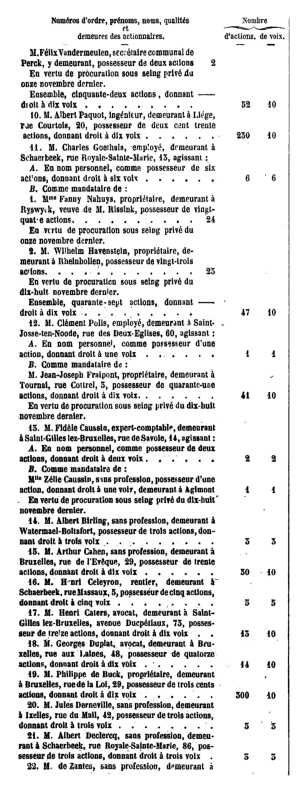

In [17]:
import pandas as pd

df = pd.DataFrame(table)
print(df)
df.to_excel("output_table.xlsx", index=False)

plt.figure(figsize=(16,10))
plt.imshow(cropped_table)
plt.axis('off')
